In [ ]:
# =============================================================================
# Instrucciones: 
#   Crear carpeta Proyecto_Sismos.
#   Agregar Earthquakes_USGS.csv a carpeta Proyecto_Sismos
#   Correr este script para instalar dependencias.
# =============================================================================
%pip install pandas matplotlib seaborn openpyxl scikit-learn

^C
Note: you may need to restart the kernel to use updated packages.


In [1]:
# =============================================================================
# Proyecto: Analítica de Datos Sísmicos Globales (1900-2025)
# Descripción: 
#   Script diseñado para procesar datasets masivos (>2GB) mediante la técnica 
#   de 'chunking' (lectura por bloques). Realiza limpieza, traducción de 
#   columnas y filtrado de 'ruido sísmico' (magnitud < 3.0).
# =============================================================================

import pandas as pd
import os

# --- 1. CONFIGURACIÓN DEL ENTORNO ---
# Nombre del archivo crudo (raw data). Asegúrate de que esté en la misma carpeta.
ARCHIVO_INPUT = 'Earthquakes_USGS.csv' 
ARCHIVO_OUTPUT = 'sismos_procesados.csv'

# Parámetros de Filtrado (Criterio de Negocio)
# Filtramos sismos menores a 3.0 para eliminar microsismos que sesgan el análisis
MAGNITUD_MINIMA = 3.0 

# Tamaño del bloque de lectura (100k filas) para gestión eficiente de RAM
CHUNK_SIZE = 100000 

# Listas auxiliares
trozos_procesados = []
contador_filas = 0

print(f"🚀 Iniciando procesamiento del archivo: {ARCHIVO_INPUT}")
print(f"⚙️ Configuración: Filtrando magnitudes >= {MAGNITUD_MINIMA} y solo eventos tipo 'earthquake'.")

try:
    # --- 2. PROCESAMIENTO ITERATIVO (CHUNKING) ---
    # Leemos el CSV en bloques para no desbordar la memoria
    csv_reader = pd.read_csv(ARCHIVO_INPUT, chunksize=CHUNK_SIZE, low_memory=False)

    for i, df_chunk in enumerate(csv_reader):
        
        contador_filas += len(df_chunk)

        # --- LIMPIEZA PRELIMINAR ---
        # Selección de columnas de interés (Mapping USGS -> Proyecto)
        cols_necesarias = ['mag', 'latitude', 'longitude', 'depth', 'time', 'place', 'type_property']
        
        # Verificamos que las columnas existan en el bloque actual
        cols_existentes = [c for c in cols_necesarias if c in df_chunk.columns]
        
        # Eliminamos nulos en variables críticas. Usamos .copy() para evitar el SettingWithCopyWarning
        df_clean = df_chunk.dropna(subset=['mag', 'latitude', 'longitude', 'depth', 'time']).copy()

        # --- TRANSFORMACIÓN DE DATOS ---
        # Normalización de Magnitud (Forzamos a numérico, errores se vuelven NaN)
        df_clean['mag'] = pd.to_numeric(df_clean['mag'], errors='coerce')

        # --- APLICACIÓN DE REGLAS DE NEGOCIO ---
        # Regla 1: Solo nos interesan terremotos naturales, no explosiones nucleares/canteras
        if 'type_property' in df_clean.columns:
            df_clean = df_clean[df_clean['type_property'] == 'earthquake']

        # Regla 2: Filtrar ruido (sismos muy pequeños)
        df_clean = df_clean[df_clean['mag'] >= MAGNITUD_MINIMA]

        # --- SELECCIÓN FINAL Y TRADUCCIÓN ---
        # Seleccionamos las columnas finales y las renombramos al español
        df_final = df_clean[['time', 'latitude', 'longitude', 'depth', 'mag', 'place']].copy()
        df_final.columns = ['fecha', 'latitud', 'longitud', 'profundidad', 'magnitud', 'lugar']

        # Guardamos el bloque procesado en la lista
        trozos_procesados.append(df_final)

        # Feedback de progreso cada 10 bloques (1 millón de filas aprox)
        if i % 10 == 0:
            print(f"   ...Procesando bloque {i}: {contador_filas:,} filas leídas hasta ahora.")

    # --- 3. CONSOLIDACIÓN Y EXPORTACIÓN ---
    print("🧩 Uniendo bloques procesados...")
    df_consolidado = pd.concat(trozos_procesados)

    # Tratamiento de Fechas (Paso crítico para análisis temporal)
    # 'format=mixed' permite manejar inconsistencias en el formato de fecha original
    print("📅 Normalizando formatos de fecha...")
    df_consolidado['fecha'] = pd.to_datetime(df_consolidado['fecha'], format='mixed').dt.date

    # Métricas finales
    print("\n" + "="*40)
    print("✅ PROCESO COMPLETADO EXITOSAMENTE")
    print("="*40)
    print(f"Total filas leídas (brutas):  {contador_filas:,}")
    print(f"Total sismos útiles (limpios): {len(df_consolidado):,}")
    print(f"Reducción de datos: {100 - (len(df_consolidado)/contador_filas*100):.2f}% de ruido eliminado.")
    print("="*40)

    # Exportación a CSV ligero
    df_consolidado.to_csv(ARCHIVO_OUTPUT, index=False)
    print(f"📂 Dataset final guardado en: {os.path.abspath(ARCHIVO_OUTPUT)}")

except FileNotFoundError:
    print(f"\n❌ ERROR: No se encontró el archivo '{ARCHIVO_INPUT}'. Verifica la ruta.")
except Exception as e:
    print(f"\n❌ ERROR INESPERADO: {e}")

🚀 Iniciando procesamiento del archivo: Earthquakes_USGS.csv
⚙️ Configuración: Filtrando magnitudes >= 3.0 y solo eventos tipo 'earthquake'.
   ...Procesando bloque 0: 100,000 filas leídas hasta ahora.
   ...Procesando bloque 10: 1,100,000 filas leídas hasta ahora.
   ...Procesando bloque 20: 2,100,000 filas leídas hasta ahora.
   ...Procesando bloque 30: 3,100,000 filas leídas hasta ahora.
   ...Procesando bloque 40: 4,100,000 filas leídas hasta ahora.
🧩 Uniendo bloques procesados...
📅 Normalizando formatos de fecha...

✅ PROCESO COMPLETADO EXITOSAMENTE
Total filas leídas (brutas):  4,358,464
Total sismos útiles (limpios): 708,734
Reducción de datos: 83.74% de ruido eliminado.
📂 Dataset final guardado en: c:\Users\tavos\OneDrive - INACAP\Desktop\Proyecto_Sismos\sismos_procesados.csv


📊 Generando visualizaciones analíticas...


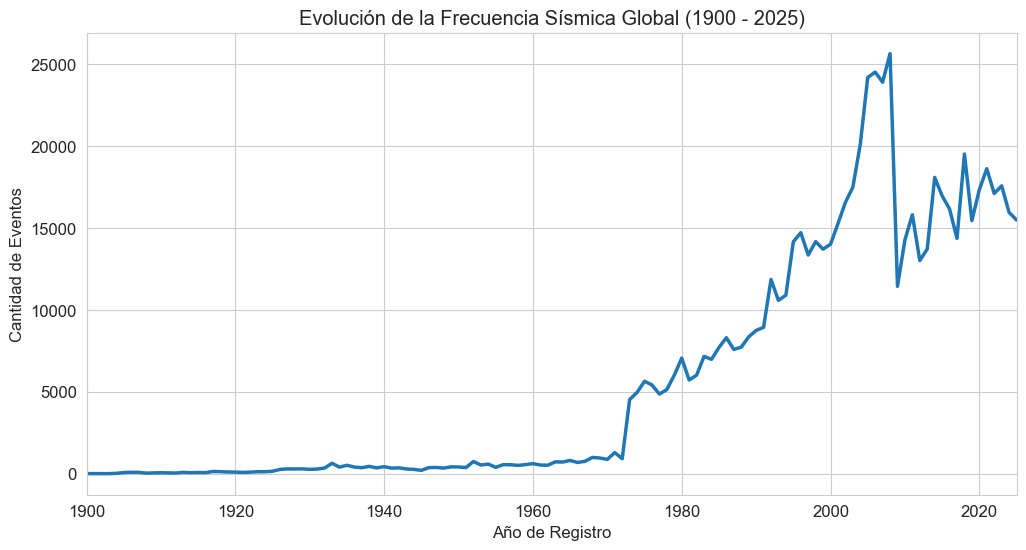

✅ Gráfico 1 guardado: Muestra el aumento de detección gracias a la tecnología moderna.


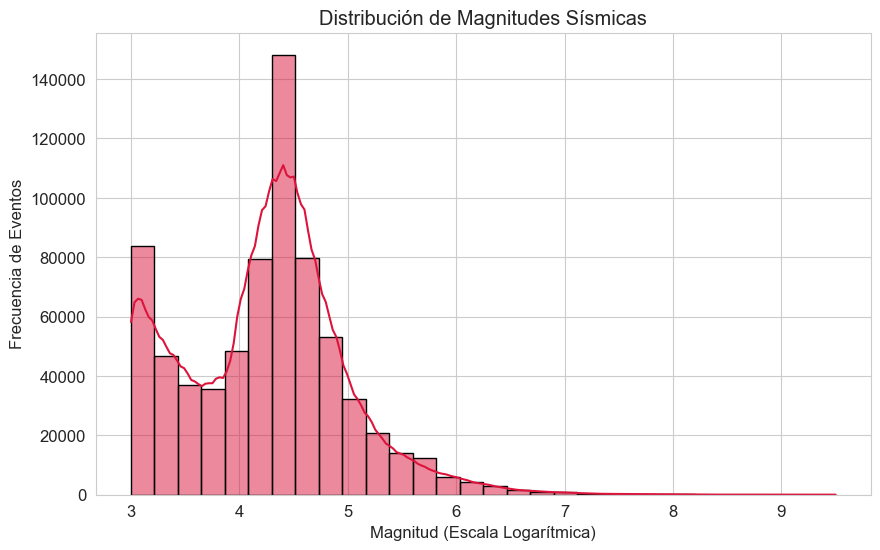

✅ Gráfico 2 guardado: Confirma que los sismos leves son más frecuentes (Sesgo a la izquierda).


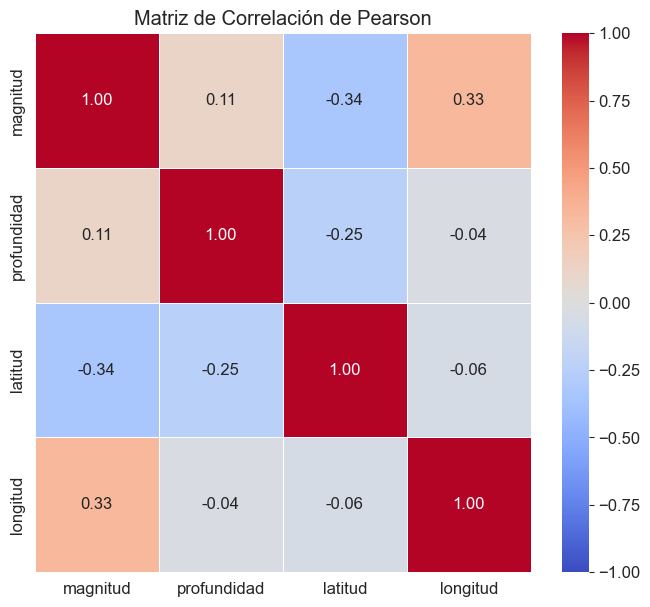

✅ Gráfico 3 guardado: Evidencia la independencia entre Profundidad y Magnitud.


In [5]:
# =============================================================================
# Proyecto: Analítica de Datos Sísmicos Globales (1900-2025)
# Descripción: 
#   Generación de visualizaciones estadísticas clave para la comprensión del 
#   fenómeno sísmico. Se producen 3 gráficos: Tendencia Temporal, Distribución 
#   de Magnitudes y Matriz de Correlaciones.
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURACIÓN ESTÉTICA ---
# Usamos el estilo 'whitegrid' para facilitar la lectura de valores en el informe
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.titlesize': 16})

ARCHIVO_INPUT = 'sismos_procesados.csv'

print("📊 Generando visualizaciones analíticas...")

try:
    # Cargar datos limpios
    df = pd.read_csv(ARCHIVO_INPUT)

    # Conversión de fecha para análisis de series de tiempo
    df['fecha'] = pd.to_datetime(df['fecha'])
    df['año'] = df['fecha'].dt.year

    # =========================================================================
    # GRÁFICO 1: ANÁLISIS DE TENDENCIA TEMPORAL
    # Objetivo: Identificar patrones de frecuencia a lo largo del siglo.
    # =========================================================================
    plt.figure(figsize=(12, 6))
    
    # Contamos sismos por año y ordenamos cronológicamente
    sismos_por_anio = df['año'].value_counts().sort_index()
    
    # Graficamos la línea de tendencia
    sns.lineplot(x=sismos_por_anio.index, y=sismos_por_anio.values, color='#1f77b4', linewidth=2.5)
    
    plt.title('Evolución de la Frecuencia Sísmica Global (1900 - 2025)')
    plt.xlabel('Año de Registro')
    plt.ylabel('Cantidad de Eventos')
    plt.xlim(df['año'].min(), df['año'].max())
    
    # Guardar imagen para el informe
    plt.savefig('Grafico_1_Tendencia_Temporal.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Gráfico 1 guardado: Muestra el aumento de detección gracias a la tecnología moderna.")

    # =========================================================================
    # GRÁFICO 2: HISTOGRAMA DE MAGNITUDES (Ley de Gutenberg-Richter)
    # Objetivo: Visualizar la distribución de frecuencias según intensidad.
    # =========================================================================
    plt.figure(figsize=(10, 6))
    
    # Histograma con curva de densidad (KDE)
    sns.histplot(df['magnitud'], bins=30, color='crimson', kde=True, edgecolor='black')
    
    plt.title('Distribución de Magnitudes Sísmicas')
    plt.xlabel('Magnitud (Escala Logarítmica)')
    plt.ylabel('Frecuencia de Eventos')
    
    # Guardar imagen
    plt.savefig('Grafico_2_Distribucion_Magnitud.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Gráfico 2 guardado: Confirma que los sismos leves son más frecuentes (Sesgo a la izquierda).")

    # =========================================================================
    # GRÁFICO 3: MATRIZ DE CORRELACIÓN (MULTIVARIADO)
    # Objetivo: Detectar relaciones lineales entre variables físicas.
    # =========================================================================
    plt.figure(figsize=(8, 7))
    
    # Filtramos solo columnas numéricas relevantes para la correlación
    cols_corr = ['magnitud', 'profundidad', 'latitud', 'longitud']
    corr_matrix = df[cols_corr].corr()
    
    # Mapa de calor con anotaciones
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
    
    plt.title('Matriz de Correlación de Pearson')
    
    # Guardar imagen
    plt.savefig('Grafico_3_Correlacion.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Gráfico 3 guardado: Evidencia la independencia entre Profundidad y Magnitud.")

except FileNotFoundError:
    print(f"❌ Error: No se encontró '{ARCHIVO_INPUT}'. Ejecuta primero el script de limpieza.")
except Exception as e:
    print(f"❌ Error inesperado: {e}")

In [2]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


🤖 Entrenando modelo de Inteligencia Artificial (K-Means)...


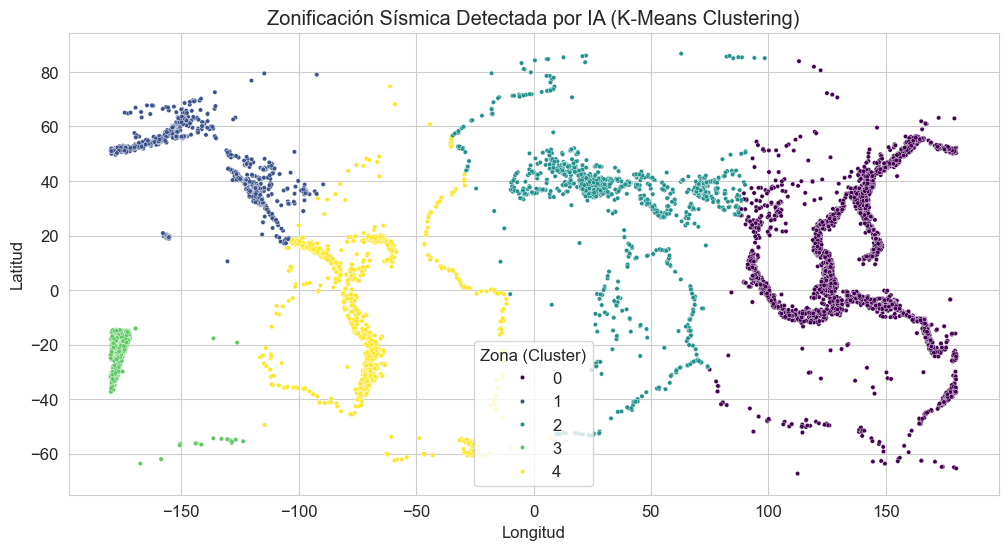

✅ Modelo entrenado y gráfico guardado.
El algoritmo K-Means agrupó los sismos basándose puramente en su ubicación geográfica, revelando las principales placas tectónicas sin necesidad de programarlas explícitamente.


In [ ]:
# =============================================================================
# CLUSTERING (K-MEANS)
# Objetivo: Identificar zonas sísmicas automáticamente sin usar fronteras políticas.
# =============================================================================

from sklearn.cluster import KMeans

print("🤖 Entrenando modelo de Inteligencia Artificial (K-Means)...")

# 1. Se preparan los datos (Latitud y Longitud)
df_modelo = df.sample(n=10000, random_state=42)
X = df_modelo[['latitud', 'longitud']]

# 2. Configuración del Modelo
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# 3. Entrenamiento
df_modelo['cluster'] = kmeans.fit_predict(X)

# 4. Visualización de los Clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_modelo, 
    x='longitud', 
    y='latitud', 
    hue='cluster', 
    palette='viridis', 
    s=10 
)
plt.title('Zonificación Sísmica Detectada por IA (K-Means Clustering)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Zona (Cluster)')
plt.savefig('Grafico_4_Clustering_IA.png', dpi=300)
plt.show()

print("✅ Modelo entrenado y gráfico guardado.")
print("El algoritmo K-Means agrupó los sismos basándose puramente en su ubicación geográfica, revelando las principales placas tectónicas.")


--- RESULTADOS DE REGRESIÓN PARA EL INFORME ---
R-Cuadrado (R²): 0.0115


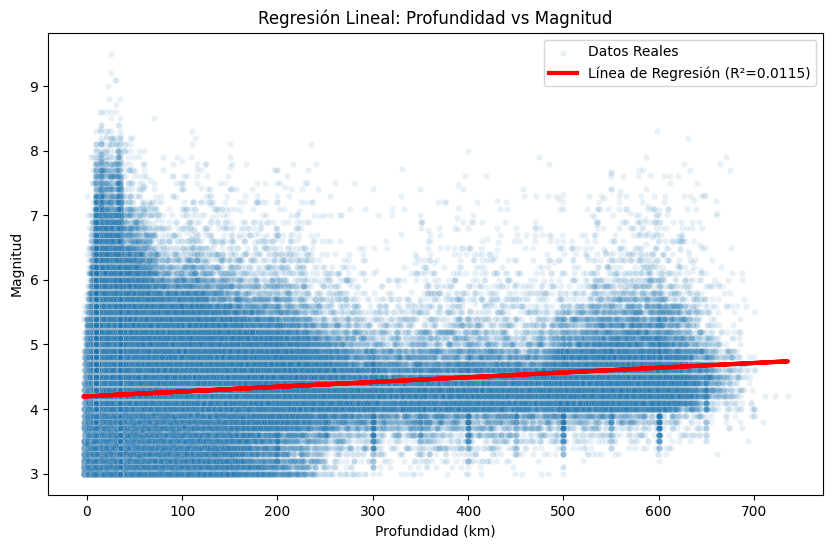


✅ CONCLUSIÓN: El R² es 0.0115 (muy bajo).
Esto confirma que NO se puede predecir la magnitud solo con la profundidad.


In [ ]:
# =============================================================================
# CÓDIGO FINAL DE REGRESIÓN LIMPIO (CORREGIDO)
# =============================================================================
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de datos
try:
    df = pd.read_csv('sismos_procesados.csv')
except FileNotFoundError:
    raise FileNotFoundError("⚠️ Asegúrate de que 'sismos_procesados.csv' esté en la carpeta (ejecuta primero la celda de limpieza).")

# 1. Definir Variables
X = df[['profundidad']] # Variable Predictora
Y = df['magnitud']      # Variable a Predecir

# 2. Dividir datos
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. Entrenar y Evaluar
modelo_reg = LinearRegression()
modelo_reg.fit(X_train, Y_train)
Y_pred = modelo_reg.predict(X_test)
R2 = r2_score(Y_test, Y_pred)

print("\n--- RESULTADOS DE REGRESIÓN PARA EL INFORME ---")
print(f"R-Cuadrado (R²): {R2:.4f}")

# 4. Visualización para Conclusión
plt.figure(figsize=(10, 6))
# Gráfico de dispersión de los datos reales
sns.scatterplot(x=df['profundidad'], y=df['magnitud'], alpha=0.1, label='Datos Reales', s=20)

# Dibujar la línea de regresión (la predicción)
# AQUÍ ESTABA EL ERROR, YA LO QUITÉ:
plt.plot(X_test, Y_pred, color='red', linewidth=3, label=f'Línea de Regresión (R²={R2:.4f})')

plt.title('Regresión Lineal: Profundidad vs Magnitud')
plt.xlabel('Profundidad (km)')
plt.ylabel('Magnitud')
plt.legend()
plt.savefig('Grafico_Regresion_Final.png', dpi=300)
plt.show()

# CONCLUSIÓN AUTOMÁTICA
if R2 < 0.1:
    print(f"\n✅ CONCLUSIÓN: El R² es {R2:.4f} (muy bajo).")
    print("Esto confirma que NO se puede predecir la magnitud solo con la profundidad.")